# 12 — Seller Analytics

## Objective

This notebook evaluates seller performance using:

- Orders and items represented
- Observed product and freight value
- Customer review outcomes
- Delivery performance
- Seller activity concentration
- Geographic distribution
- Multi-seller order considerations

## Methodological limitation

Reviews and delivery timestamps are recorded at the order level rather than separately for each seller. Seller-level experience metrics therefore represent orders associated with a seller and should not be interpreted as proving that an individual seller caused a rating or delivery outcome.

## 1. Data Loading

Load the seller, seller-order bridge, and order-level analytical tables required to evaluate seller activity, value, delivery performance, and customer feedback.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.ticker import PercentFormatter

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

DATA_DIR = Path("../data/processed")
IMAGES_DIR = Path("../images/notebook_outputs")

IMAGES_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {
    "primary": "#173F5F",
    "secondary": "#20639B",
    "accent": "#F6C85F",
    "positive": "#3CAEA3",
    "negative": "#ED553B",
    "neutral": "#8A8A8A"
}

seller_analytics = pd.read_csv(
    DATA_DIR / "seller_analytics.csv"
)

seller_order_bridge = pd.read_csv(
    DATA_DIR / "seller_order_bridge.csv"
)

order_analytics = pd.read_csv(
    DATA_DIR / "order_analytics.csv",
    parse_dates=["order_purchase_timestamp"]
)

dataset_summary = pd.DataFrame({
    "dataset": [
        "seller_analytics",
        "seller_order_bridge",
        "order_analytics"
    ],
    "rows": [
        len(seller_analytics),
        len(seller_order_bridge),
        len(order_analytics)
    ],
    "columns": [
        seller_analytics.shape[1],
        seller_order_bridge.shape[1],
        order_analytics.shape[1]
    ]
})

display(
    dataset_summary.style.format({
        "rows": "{:,.0f}",
        "columns": "{:,.0f}"
    })
)

print(
    "Unique sellers:",
    f"{seller_analytics['seller_id'].nunique():,}"
)
print(
    "Bridge sellers:",
    f"{seller_order_bridge['seller_id'].nunique():,}"
)

,dataset,rows,columns
0,seller_analytics,"3,095",20
1,seller_order_bridge,"100,010",23
2,order_analytics,"99,441",60


Unique sellers: 3,095
Bridge sellers: 3,095


## 2. Seller-Order Bridge Validation

Validate the seller–order relationship to confirm that each combination is unique and that all sellers and orders reconcile with the analytical source tables.

In [2]:
bridge_validation = pd.DataFrame([
    {
        "validation_check":
            "Duplicate seller-order combinations",
        "result": seller_order_bridge[
            ["seller_id", "order_id"]
        ].duplicated().sum(),
        "expected": 0
    },
    {
        "validation_check":
            "Seller records represented",
        "result": seller_order_bridge[
            "seller_id"
        ].nunique(),
        "expected": seller_analytics[
            "seller_id"
        ].nunique()
    },
    {
        "validation_check":
            "Bridge orders missing from order table",
        "result": (
            ~seller_order_bridge["order_id"].isin(
                order_analytics["order_id"]
            )
        ).sum(),
        "expected": 0
    }
])

bridge_validation["status"] = np.where(
    bridge_validation["result"]
    == bridge_validation["expected"],
    "Passed",
    "Failed"
)

display(bridge_validation)

print("Seller-order bridge columns:")
for column in seller_order_bridge.columns:
    print("-", column)

,validation_check,result,expected,status
0,Duplicate seller-order combinations,0,0,Passed
1,Seller records represented,3095,3095,Passed
2,Bridge orders missing from order table,0,0,Passed


Seller-order bridge columns:
- seller_id
- order_id
- seller_order_item_count
- seller_order_product_count
- seller_order_product_value
- seller_order_freight_value
- seller_order_total_value
- order_status
- order_purchase_timestamp
- customer_unique_id
- customer_state
- latest_review_score
- delivery_days
- delivery_delay_days
- is_late_delivery
- is_valid_for_delivery_analysis
- seller_zip_code_prefix
- seller_city
- seller_state
- is_delivered_order
- has_valid_review_score
- has_valid_delivery_metric
- late_delivery_flag_numeric


## 3. Seller Performance Table

Aggregate seller-order records into one row per seller while preserving seller-specific item values and treating reviews and delivery outcomes as associated order-level measures.

In [3]:
order_seller_counts = (
    seller_order_bridge
    .groupby("order_id")["seller_id"]
    .nunique()
)

seller_bridge = seller_order_bridge.copy()

seller_bridge["order_seller_count"] = (
    seller_bridge["order_id"]
    .map(order_seller_counts)
)

seller_bridge["is_multi_seller_order"] = (
    seller_bridge["order_seller_count"] > 1
)

seller_bridge["review_score_for_analysis"] = (
    seller_bridge["latest_review_score"]
    .where(
        seller_bridge["is_delivered_order"]
        & seller_bridge["has_valid_review_score"]
    )
)

seller_bridge["low_satisfaction_for_analysis"] = (
    seller_bridge["review_score_for_analysis"]
    .le(2)
    .where(
        seller_bridge[
            "review_score_for_analysis"
        ].notna()
    )
)

seller_bridge["late_delivery_for_analysis"] = (
    pd.to_numeric(
        seller_bridge["late_delivery_flag_numeric"],
        errors="coerce"
    )
    .where(
        seller_bridge["is_delivered_order"]
        & seller_bridge["has_valid_delivery_metric"]
    )
)

seller_bridge["delivery_days_for_analysis"] = (
    seller_bridge["delivery_days"]
    .where(
        seller_bridge["is_delivered_order"]
        & seller_bridge["has_valid_delivery_metric"]
    )
)

seller_performance = (
    seller_bridge
    .groupby("seller_id", as_index=False)
    .agg(
        seller_city=("seller_city", "first"),
        seller_state=("seller_state", "first"),
        recorded_orders=("order_id", "nunique"),
        delivered_orders=("is_delivered_order", "sum"),
        item_records=("seller_order_item_count", "sum"),
        distinct_products=(
            "seller_order_product_count",
            "sum"
        ),
        product_value=(
            "seller_order_product_value",
            "sum"
        ),
        freight_value=(
            "seller_order_freight_value",
            "sum"
        ),
        reviewed_delivered_orders=(
            "review_score_for_analysis",
            "count"
        ),
        average_review_score=(
            "review_score_for_analysis",
            "mean"
        ),
        low_satisfaction_rate=(
            "low_satisfaction_for_analysis",
            "mean"
        ),
        valid_delivery_orders=(
            "late_delivery_for_analysis",
            "count"
        ),
        late_delivery_rate=(
            "late_delivery_for_analysis",
            "mean"
        ),
        average_delivery_days=(
            "delivery_days_for_analysis",
            "mean"
        ),
        multi_seller_order_rate=(
            "is_multi_seller_order",
            "mean"
        )
    )
)

seller_performance["delivered_order_rate"] = (
    seller_performance["delivered_orders"]
    / seller_performance["recorded_orders"]
)

seller_validation = pd.DataFrame([
    {
        "validation_check": "Sellers represented",
        "result": len(seller_performance),
        "expected": 3_095
    },
    {
        "validation_check": "Duplicate seller IDs",
        "result": seller_performance[
            "seller_id"
        ].duplicated().sum(),
        "expected": 0
    },
    {
        "validation_check": "Item records represented",
        "result": seller_performance[
            "item_records"
        ].sum(),
        "expected": seller_bridge[
            "seller_order_item_count"
        ].sum()
    },
    {
        "validation_check": "Product value represented",
        "result": round(
            seller_performance["product_value"].sum(),
            2
        ),
        "expected": round(
            seller_bridge[
                "seller_order_product_value"
            ].sum(),
            2
        )
    },
    {
        "validation_check": "Freight value represented",
        "result": round(
            seller_performance["freight_value"].sum(),
            2
        ),
        "expected": round(
            seller_bridge[
                "seller_order_freight_value"
            ].sum(),
            2
        )
    }
])

seller_validation["status"] = np.where(
    seller_validation["result"]
    == seller_validation["expected"],
    "Passed",
    "Failed"
)

display(seller_validation)

print(
    "Seller performance rows:",
    f"{len(seller_performance):,}"
)

,validation_check,result,expected,status
0,Sellers represented,"3,095.00","3,095.00",Passed
1,Duplicate seller IDs,0.00,0.00,Passed
2,Item records represented,"112,650.00","112,650.00",Passed
3,Product value represented,"13,591,643.70","13,591,643.70",Passed
4,Freight value represented,"2,251,909.54","2,251,909.54",Passed


Seller performance rows: 3,095


## 4. Seller Activity Distribution

Examine the distribution of seller orders, product value, reviews, and valid deliveries to identify volume differences and determine whether minimum comparison thresholds are necessary.

In [4]:
seller_performance = seller_performance.rename(
    columns={
        "distinct_products":
            "order_product_combinations"
    }
)

distribution_columns = [
    "recorded_orders",
    "delivered_orders",
    "item_records",
    "order_product_combinations",
    "product_value",
    "freight_value",
    "reviewed_delivered_orders",
    "average_review_score",
    "valid_delivery_orders",
    "late_delivery_rate"
]

seller_distribution = (
    seller_performance[
        distribution_columns
    ]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
    .T
)

display(
    seller_distribution.style.format(
        "{:,.2f}"
    )
)

seller_activity_summary = pd.DataFrame({
    "metric": [
        "Sellers represented",
        "Sellers with delivered orders",
        "Median recorded orders per seller",
        "90th-percentile recorded orders",
        "Maximum recorded orders",
        "Median observed product value",
        "90th-percentile observed product value",
        "Maximum observed product value"
    ],
    "value": [
        len(seller_performance),
        (
            seller_performance[
                "delivered_orders"
            ] > 0
        ).sum(),
        seller_performance[
            "recorded_orders"
        ].median(),
        seller_performance[
            "recorded_orders"
        ].quantile(0.90),
        seller_performance[
            "recorded_orders"
        ].max(),
        seller_performance[
            "product_value"
        ].median(),
        seller_performance[
            "product_value"
        ].quantile(0.90),
        seller_performance[
            "product_value"
        ].max()
    ]
})

display(
    seller_activity_summary.style.format({
        "value": "{:,.2f}"
    })
)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
recorded_orders,"3,095.00",32.31,105.14,1.00,2.00,6.00,21.50,69.60,130.30,402.24,"1,854.00"
delivered_orders,"3,095.00",31.61,103.46,0.00,2.00,6.00,21.00,68.60,128.30,394.24,"1,819.00"
item_records,"3,095.00",36.40,119.19,1.00,2.00,8.00,24.00,80.00,146.60,431.24,"2,033.00"
order_product_combinations,"3,095.00",33.09,108.60,1.00,2.00,7.00,22.00,72.00,134.00,415.30,"1,982.00"
product_value,"3,095.00","4,391.48","13,922.00",3.50,208.85,821.48,"3,280.83","9,525.32","16,260.66","55,108.72","229,472.63"
freight_value,"3,095.00",727.60,"2,327.16",6.66,46.17,155.52,558.17,"1,653.71","2,913.19","8,880.34","51,612.55"
reviewed_delivered_orders,"3,095.00",31.39,102.77,0.00,2.00,6.00,21.00,68.00,127.30,393.18,"1,805.00"
average_review_score,"2,965.00",4.18,0.78,1.00,3.97,4.28,4.67,5.00,5.00,5.00,5.00
valid_delivery_orders,"3,095.00",31.53,103.32,0.00,2.00,6.00,21.00,68.60,128.00,391.42,"1,815.00"
late_delivery_rate,"2,965.00",0.07,0.16,0.00,0.00,0.00,0.08,0.18,0.33,1.00,1.00


,metric,value
0,Sellers represented,"3,095.00"
1,Sellers with delivered orders,"2,970.00"
2,Median recorded orders per seller,6.00
3,90th-percentile recorded orders,69.60
4,Maximum recorded orders,"1,854.00"
5,Median observed product value,821.48
6,90th-percentile observed product value,"9,525.32"
7,Maximum observed product value,"229,472.63"


***Observation:*** Seller activity and value are strongly concentrated: the median seller records only 6 orders and R$821.48 in product value, while the largest seller reaches 1,854 orders and R$229,472.63. Because most sellers have limited review and delivery observations, unfiltered seller-level rates can be unstable and should not be used for direct performance comparisons.

## 5. Reliable Seller Comparison Group

Restrict review and delivery comparisons to sellers with sufficient observations, reducing the instability created by very small seller samples.

In [5]:
seller_bridge["delivered_product_value"] = (
    seller_bridge[
        "seller_order_product_value"
    ].where(
        seller_bridge["is_delivered_order"],
        0
    )
)

seller_bridge["delivered_freight_value"] = (
    seller_bridge[
        "seller_order_freight_value"
    ].where(
        seller_bridge["is_delivered_order"],
        0
    )
)

delivered_seller_financials = (
    seller_bridge
    .groupby("seller_id", as_index=False)
    .agg(
        delivered_product_value=(
            "delivered_product_value",
            "sum"
        ),
        delivered_freight_value=(
            "delivered_freight_value",
            "sum"
        )
    )
)

seller_performance = (
    seller_performance
    .merge(
        delivered_seller_financials,
        on="seller_id",
        how="left",
        validate="one_to_one"
    )
)

minimum_reviewed_orders = 50
minimum_valid_deliveries = 50

reliable_sellers = (
    seller_performance.loc[
        (
            seller_performance[
                "reviewed_delivered_orders"
            ] >= minimum_reviewed_orders
        )
        & (
            seller_performance[
                "valid_delivery_orders"
            ] >= minimum_valid_deliveries
        )
    ]
    .copy()
)

reliable_seller_validation = pd.DataFrame([
    {
        "validation_check":
            "Duplicate reliable seller IDs",
        "result": reliable_sellers[
            "seller_id"
        ].duplicated().sum(),
        "expected": 0
    },
    {
        "validation_check":
            "Reliable sellers below review threshold",
        "result": (
            reliable_sellers[
                "reviewed_delivered_orders"
            ] < minimum_reviewed_orders
        ).sum(),
        "expected": 0
    },
    {
        "validation_check":
            "Reliable sellers below delivery threshold",
        "result": (
            reliable_sellers[
                "valid_delivery_orders"
            ] < minimum_valid_deliveries
        ).sum(),
        "expected": 0
    },
    {
        "validation_check":
            "Delivered product value represented",
        "result": round(
            seller_performance[
                "delivered_product_value"
            ].sum(),
            2
        ),
        "expected": round(
            seller_bridge[
                "delivered_product_value"
            ].sum(),
            2
        )
    }
])

reliable_seller_validation["status"] = np.where(
    reliable_seller_validation["result"]
    == reliable_seller_validation["expected"],
    "Passed",
    "Failed"
)

display(reliable_seller_validation)

print(
    "Sellers meeting both thresholds:",
    f"{len(reliable_sellers):,}"
)
print(
    "Share of all sellers:",
    f"{len(reliable_sellers) / len(seller_performance):.2%}"
)

,validation_check,result,expected,status
0,Duplicate reliable seller IDs,0.00,0.00,Passed
1,Reliable sellers below review threshold,0.00,0.00,Passed
2,Reliable sellers below delivery threshold,0.00,0.00,Passed
3,Delivered product value represented,"13,221,498.11","13,221,498.11",Passed


Sellers meeting both thresholds: 417
Share of all sellers: 13.47%


***Validation result:*** All reliability and reconciliation checks passed. The final comparison group contains 417 sellers (13.47% of all sellers), each with at least 50 reviewed delivered orders and 50 valid delivery observations; the delivered product value also reconciles exactly to R$13.22 million.

## 6. Seller Value Concentration

Measure how delivered product value and seller-order activity are distributed across sellers, without interpreting product value as profit or net revenue.

In [6]:
ranked_sellers = (
    seller_performance
    .sort_values(
        "delivered_product_value",
        ascending=False
    )
    .reset_index(drop=True)
    .copy()
)

ranked_sellers["seller_rank"] = (
    np.arange(1, len(ranked_sellers) + 1)
)

ranked_sellers["cumulative_seller_share"] = (
    ranked_sellers["seller_rank"]
    / len(ranked_sellers)
)

ranked_sellers["cumulative_product_value_share"] = (
    ranked_sellers[
        "delivered_product_value"
    ].cumsum()
    / ranked_sellers[
        "delivered_product_value"
    ].sum()
)

concentration_levels = [
    ("Top 1%", 0.01),
    ("Top 5%", 0.05),
    ("Top 10%", 0.10),
    ("Top 20%", 0.20),
    ("Top 50%", 0.50)
]

seller_concentration_records = []

for label, seller_share in concentration_levels:
    seller_count = int(
        np.ceil(
            len(ranked_sellers) * seller_share
        )
    )

    selected_sellers = ranked_sellers.iloc[
        :seller_count
    ]

    seller_concentration_records.append({
        "seller_group": label,
        "sellers": seller_count,
        "seller_share": (
            seller_count / len(ranked_sellers)
        ),
        "minimum_delivered_product_value": (
            selected_sellers[
                "delivered_product_value"
            ].min()
        ),
        "delivered_product_value": (
            selected_sellers[
                "delivered_product_value"
            ].sum()
        ),
        "product_value_share": (
            selected_sellers[
                "delivered_product_value"
            ].sum()
            / ranked_sellers[
                "delivered_product_value"
            ].sum()
        ),
        "delivered_orders": (
            selected_sellers[
                "delivered_orders"
            ].sum()
        ),
        "seller_order_share": (
            selected_sellers[
                "delivered_orders"
            ].sum()
            / ranked_sellers[
                "delivered_orders"
            ].sum()
        )
    })

seller_concentration = pd.DataFrame(
    seller_concentration_records
)

display(
    seller_concentration.style.format({
        "sellers": "{:,.0f}",
        "seller_share": "{:.2%}",
        "minimum_delivered_product_value":
            "R$ {:,.2f}",
        "delivered_product_value":
            "R$ {:,.2f}",
        "product_value_share": "{:.2%}",
        "delivered_orders": "{:,.0f}",
        "seller_order_share": "{:.2%}"
    })
)

,seller_group,sellers,seller_share,minimum_delivered_product_value,delivered_product_value,product_value_share,delivered_orders,seller_order_share
0,Top 1%,31,1.00%,"R$ 54,435.66","R$ 3,482,099.71",26.34%,"21,862",22.35%
1,Top 5%,155,5.01%,"R$ 16,040.84","R$ 7,113,615.77",53.80%,"45,261",46.27%
2,Top 10%,310,10.02%,"R$ 9,253.47","R$ 8,994,978.42",68.03%,"59,832",61.17%
3,Top 20%,619,20.00%,"R$ 4,353.90","R$ 10,991,902.90",83.14%,"75,937",77.63%
4,Top 50%,"1,548",50.02%,R$ 783.10,"R$ 12,835,260.46",97.08%,"92,679",94.75%


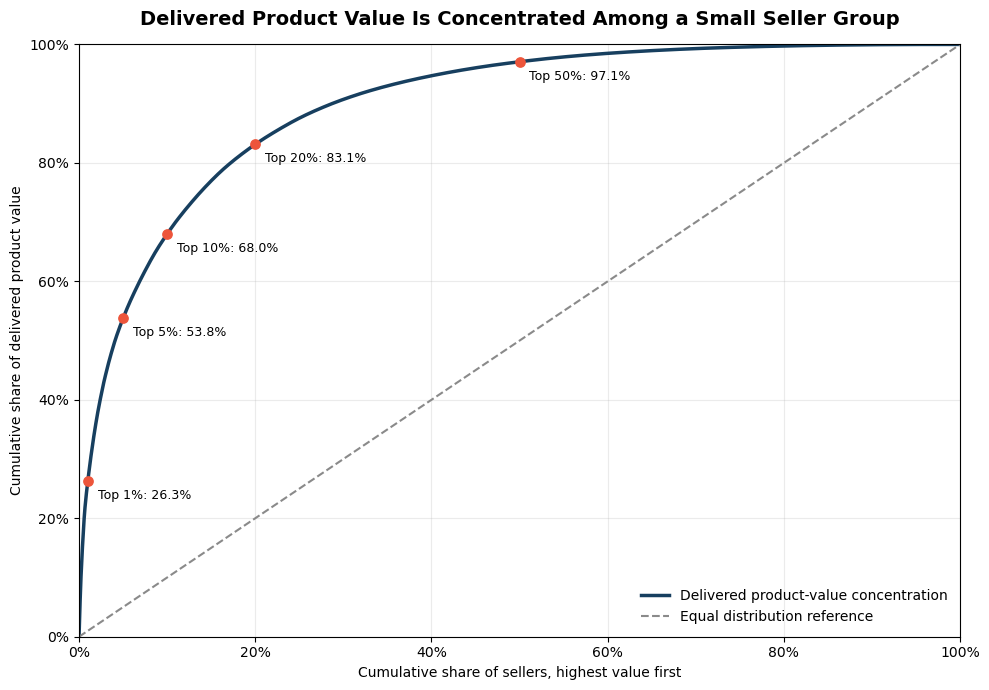

In [7]:
curve_x = np.concatenate([
    [0],
    ranked_sellers[
        "cumulative_seller_share"
    ].to_numpy()
])

curve_y = np.concatenate([
    [0],
    ranked_sellers[
        "cumulative_product_value_share"
    ].to_numpy()
])

fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(
    curve_x,
    curve_y,
    color=COLORS["primary"],
    linewidth=2.5,
    label="Delivered product-value concentration"
)

ax.plot(
    [0, 1],
    [0, 1],
    color=COLORS["neutral"],
    linestyle="--",
    linewidth=1.5,
    label="Equal distribution reference"
)

for _, row in seller_concentration.iterrows():
    ax.scatter(
        row["seller_share"],
        row["product_value_share"],
        color=COLORS["negative"],
        s=45,
        zorder=3
    )

    ax.annotate(
        (
            f"{row['seller_group']}: "
            f"{row['product_value_share']:.1%}"
        ),
        xy=(
            row["seller_share"],
            row["product_value_share"]
        ),
        xytext=(7, -13),
        textcoords="offset points",
        fontsize=9
    )

ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.yaxis.set_major_formatter(PercentFormatter(1))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.set_xlabel("Cumulative share of sellers, highest value first")
ax.set_ylabel("Cumulative share of delivered product value")

ax.set_title(
    "Delivered Product Value Is Concentrated Among a Small Seller Group",
    fontsize=14,
    fontweight="bold",
    pad=14
)

ax.legend(frameon=False, loc="lower right")
ax.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    IMAGES_DIR / "seller_product_value_concentration.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

***Observation:*** When sellers are ranked by delivered product value, the top 5% account for 53.80% of value and the top 20% account for 83.14%. These amounts represent item prices associated with delivered orders, not seller profit, commission, or net revenue.

## 7. High-Value Seller Activity

Identify sellers associated with the largest delivered product values and review their order volume, customer ratings, and delivery outcomes without treating product value as profit or overall seller quality.

In [8]:
seller_performance["product_value_share"] = (
    seller_performance[
        "delivered_product_value"
    ]
    / seller_performance[
        "delivered_product_value"
    ].sum()
)

top_value_sellers = (
    seller_performance
    .sort_values(
        "delivered_product_value",
        ascending=False
    )
    .head(10)
    [
        [
            "seller_id",
            "seller_city",
            "seller_state",
            "delivered_orders",
            "delivered_product_value",
            "product_value_share",
            "average_review_score",
            "low_satisfaction_rate",
            "late_delivery_rate",
            "multi_seller_order_rate"
        ]
    ]
    .reset_index(drop=True)
)

display(
    top_value_sellers.style.format({
        "delivered_orders": "{:,.0f}",
        "delivered_product_value": "R$ {:,.2f}",
        "product_value_share": "{:.2%}",
        "average_review_score": "{:.2f}",
        "low_satisfaction_rate": "{:.2%}",
        "late_delivery_rate": "{:.2%}",
        "multi_seller_order_rate": "{:.2%}"
    })
)

print(
    "Top-10 delivered product-value share:",
    f"{top_value_sellers['product_value_share'].sum():.2%}"
)

,seller_id,seller_city,seller_state,delivered_orders,delivered_product_value,product_value_share,average_review_score,low_satisfaction_rate,late_delivery_rate,multi_seller_order_rate
0,4869f7a5dfa277a7dca6462dcf3b52b2,guariba,SP,"1,124","R$ 226,987.93",1.72%,4.15,13.08%,10.50%,1.15%
1,53243585a1d6dc2643021fd1853d8905,lauro de freitas,BA,348,"R$ 217,940.44",1.65%,4.19,10.40%,3.45%,0.00%
2,4a3ca9315b744ce9f8e9374361493884,ibitinga,SP,"1,772","R$ 196,882.12",1.49%,3.85,18.48%,9.72%,5.48%
3,fa1c13f2614d7b5c4749cbc52fecda94,sumare,SP,578,"R$ 190,917.14",1.44%,4.37,9.58%,9.17%,2.05%
4,7c67e1448b00f6e969d365cea6b010ab,itaquaquecetuba,SP,973,"R$ 186,570.05",1.41%,3.50,25.44%,9.16%,1.02%
5,7e93a43ef30c4f03f38b393420bc753a,barueri,SP,319,"R$ 165,981.49",1.26%,4.36,8.18%,4.70%,1.19%
6,da8622b14eb17ae2831f4ac5b9dab84a,piracicaba,SP,"1,311","R$ 159,816.87",1.21%,4.18,11.72%,6.64%,2.97%
7,7a67c85e85bb2ce8582c35f2203ad736,sao paulo,SP,"1,145","R$ 139,658.69",1.06%,4.28,9.85%,5.24%,2.16%
8,1025f0e2d44d7041d6cf58b6550e0bfa,sao paulo,SP,910,"R$ 138,208.56",1.05%,4.01,16.96%,7.92%,3.39%
9,955fee9216a65b617aa5c0531780ce60,sao paulo,SP,"1,261","R$ 131,836.71",1.00%,4.20,10.22%,6.12%,0.70%


Top-10 delivered product-value share: 13.27%


***Observation:*** The ten sellers with the largest delivered product values account for 13.27% of total delivered product value. Their experience metrics vary considerably: average review scores range from 3.50 to 4.37 and late-delivery rates range from 3.45% to 10.50%, showing that high transaction value does not necessarily correspond to consistently stronger customer outcomes.

## 8. Seller Review Performance

Compare the highest and lowest observed review outcomes among sellers meeting the minimum-volume thresholds, while treating ratings as order-level outcomes associated with each seller.

In [9]:
review_columns = [
    "seller_id",
    "seller_city",
    "seller_state",
    "reviewed_delivered_orders",
    "average_review_score",
    "low_satisfaction_rate",
    "late_delivery_rate",
    "delivered_product_value"
]

lowest_review_sellers = (
    reliable_sellers
    .nsmallest(
        10,
        "average_review_score"
    )[review_columns]
    .reset_index(drop=True)
)

highest_review_sellers = (
    reliable_sellers
    .nlargest(
        10,
        "average_review_score"
    )[review_columns]
    .reset_index(drop=True)
)

review_format = {
    "reviewed_delivered_orders": "{:,.0f}",
    "average_review_score": "{:.2f}",
    "low_satisfaction_rate": "{:.2%}",
    "late_delivery_rate": "{:.2%}",
    "delivered_product_value": "R$ {:,.2f}"
}

print("Lowest observed average review scores")
display(
    lowest_review_sellers.style.format(
        review_format
    )
)

print("Highest observed average review scores")
display(
    highest_review_sellers.style.format(
        review_format
    )
)

Lowest observed average review scores


,seller_id,seller_city,seller_state,reviewed_delivered_orders,average_review_score,low_satisfaction_rate,late_delivery_rate,delivered_product_value
0,1ca7077d890b907f89be8c954a02686a,santana de parnaiba,SP,107,2.39,59.81%,16.67%,"R$ 12,474.64"
1,2eb70248d66e0e3ef83659f71b244378,campinas,SP,184,2.79,47.28%,11.23%,"R$ 38,990.72"
2,972d0f9cf61b499a4812cf0bfa3ad3c4,brusque,SC,79,3.03,41.77%,11.11%,"R$ 7,910.42"
3,a49928bcdf77c55c6d6e05e09a9b4ca5,sao paulo,SP,96,3.03,40.62%,21.88%,"R$ 8,646.90"
4,54965bbe3e4f07ae045b90b0b8541f52,foz do iguacu,PR,69,3.14,40.58%,30.14%,"R$ 10,351.70"
5,bbad7e518d7af88a0897397ffdca1979,sao paulo,SP,67,3.18,40.30%,16.18%,"R$ 4,426.32"
6,5058e8c1e82653974541e83690655b4a,itaquaquecetuba,SP,61,3.25,31.15%,11.29%,"R$ 9,812.83"
7,8444e55c1f13cd5c179851e5ca5ebd00,congonhal,MG,92,3.37,32.61%,6.52%,"R$ 21,480.96"
8,6fd52c528dcb38be2eea044946b811f8,sao paulo,SP,66,3.39,36.36%,13.43%,"R$ 7,743.02"
9,712e6ed8aa4aa1fa65dab41fed5737e4,videira,SC,76,3.39,35.53%,20.78%,"R$ 39,385.00"


Highest observed average review scores


,seller_id,seller_city,seller_state,reviewed_delivered_orders,average_review_score,low_satisfaction_rate,late_delivery_rate,delivered_product_value
0,d13e50eaa47b4cbe9eb81465865d8cfc,santo andre,SP,66,4.82,3.03%,9.23%,"R$ 7,073.05"
1,d9bd94811c3338dceb4181f3dbc0c73e,sao paulo,SP,54,4.80,3.70%,5.56%,"R$ 6,911.02"
2,d566c37fa119d5e66c4e9052e83ee4ea,sao paulo,SP,64,4.69,3.12%,0.00%,"R$ 5,145.70"
3,376a891762bbdecbc02b4b6adec3fdda,goiania,GO,57,4.67,1.75%,3.51%,"R$ 6,406.23"
4,ac3508719a1d8f5b7614b798f70af136,canoas,RS,100,4.64,3.00%,1.98%,"R$ 12,446.14"
5,116ccb1a1604bc88e4d234a8c23f33de,sao bernardo do campo,SP,61,4.64,3.28%,3.33%,"R$ 2,004.89"
6,516e7738bd8f735ac19a010ee5450d8d,rio de janeiro,RJ,74,4.64,2.70%,2.70%,"R$ 6,463.19"
7,1bb2bdb95f4841f1bba2c0d2cd83d3c9,sao paulo,SP,78,4.63,3.85%,6.33%,"R$ 4,905.76"
8,080199a181c46c657dc5aa235411be3b,osasco,SP,78,4.62,1.28%,1.28%,"R$ 14,504.20"
9,5b925e1d006e9476d738aa200751b73b,sao paulo,SP,63,4.60,4.76%,6.35%,"R$ 7,748.50"


***Observation:*** Among sellers meeting the minimum-volume thresholds, average review scores range from 2.39 to 4.82. Sellers with the lowest observed averages also show substantially higher low-satisfaction rates, but their delivery results vary, indicating that late delivery alone does not fully explain the review differences.

## 9. Seller Delivery Performance

Identify reliable sellers associated with the highest late-delivery rates and compare them with the overall valid-order benchmark, without assigning sole responsibility for order-level delivery outcomes.

In [10]:
overall_late_delivery_rate = (
    pd.to_numeric(
        order_analytics.loc[
            (
                order_analytics["order_status"]
                == "delivered"
            )
            & (
                order_analytics[
                    "is_valid_for_delivery_analysis"
                ]
            ),
            "late_delivery_flag_numeric"
        ],
        errors="coerce"
    )
    .mean()
)

delivery_columns = [
    "seller_id",
    "seller_city",
    "seller_state",
    "valid_delivery_orders",
    "late_delivery_rate",
    "average_delivery_days",
    "average_review_score",
    "low_satisfaction_rate",
    "delivered_product_value"
]

highest_late_rate_sellers = (
    reliable_sellers
    .nlargest(
        10,
        "late_delivery_rate"
    )[delivery_columns]
    .reset_index(drop=True)
)

display(
    highest_late_rate_sellers.style.format({
        "valid_delivery_orders": "{:,.0f}",
        "late_delivery_rate": "{:.2%}",
        "average_delivery_days": "{:.2f}",
        "average_review_score": "{:.2f}",
        "low_satisfaction_rate": "{:.2%}",
        "delivered_product_value": "R$ {:,.2f}"
    })
)

print(
    "Overall valid-order late-delivery rate:",
    f"{overall_late_delivery_rate:.2%}"
)

,seller_id,seller_city,seller_state,valid_delivery_orders,late_delivery_rate,average_delivery_days,average_review_score,low_satisfaction_rate,delivered_product_value
0,54965bbe3e4f07ae045b90b0b8541f52,foz do iguacu,PR,73,30.14%,26.17,3.14,40.58%,"R$ 10,351.70"
1,beadbee30901a7f61d031b6b686095ad,guarulhos,SP,64,23.44%,14.10,3.91,18.75%,"R$ 4,373.98"
2,a49928bcdf77c55c6d6e05e09a9b4ca5,sao paulo,SP,96,21.88%,16.93,3.03,40.62%,"R$ 8,646.90"
3,712e6ed8aa4aa1fa65dab41fed5737e4,videira,SC,77,20.78%,24.69,3.39,35.53%,"R$ 39,385.00"
4,06a2c3af7b3aee5d69171b0e14f0ee87,sao luis,MA,385,19.22%,17.78,4.01,16.10%,"R$ 36,097.98"
5,002100f778ceb8431b7a1020ff7ab48f,franca,SP,50,18.00%,16.39,3.96,14.00%,"R$ 1,216.60"
6,ea566164622c6b439516ab18062c42cd,sao paulo,SP,50,18.00%,14.03,3.78,24.00%,"R$ 10,309.42"
7,cac4c8e7b1ca6252d8f20b2fc1a2e4af,indaiatuba,SP,74,17.57%,18.22,3.56,28.77%,"R$ 4,128.19"
8,6039e27294dc75811c0d8a39069f52c0,osasco,SP,63,17.46%,17.99,3.73,19.05%,"R$ 13,500.80"
9,88460e8ebdecbfecb5f9601833981930,maringa,PR,244,17.21%,17.90,3.43,30.61%,"R$ 31,320.40"


Overall valid-order late-delivery rate: 6.78%


***Observation:*** The highest reliable seller-associated late-delivery rate is 30.14%, compared with the overall valid-order benchmark of 6.78%. Several sellers with elevated late-delivery rates also have lower review scores and higher low-satisfaction rates, but the order-level data does not establish sole seller responsibility.

## 10. Seller Performance Matrix

Combine delivery and review outcomes to identify reliable sellers associated with both above-benchmark late-delivery rates and below-benchmark review scores for further investigation.

In [11]:
overall_review_score = (
    order_analytics.loc[
        (
            order_analytics["order_status"]
            == "delivered"
        )
        & order_analytics[
            "latest_review_score"
        ].notna(),
        "latest_review_score"
    ]
    .mean()
)

reliable_sellers["performance_group"] = np.select(
    [
        (
            reliable_sellers[
                "late_delivery_rate"
            ] > overall_late_delivery_rate
        )
        & (
            reliable_sellers[
                "average_review_score"
            ] < overall_review_score
        ),
        (
            reliable_sellers[
                "late_delivery_rate"
            ] <= overall_late_delivery_rate
        )
        & (
            reliable_sellers[
                "average_review_score"
            ] >= overall_review_score
        )
    ],
    [
        "Higher late rate and lower review score",
        "Lower late rate and higher review score"
    ],
    default="Mixed performance"
)

seller_priority_candidates = (
    reliable_sellers.loc[
        reliable_sellers["performance_group"]
        == "Higher late rate and lower review score"
    ]
    .sort_values(
        "delivered_product_value",
        ascending=False
    )
    [
        [
            "seller_id",
            "seller_city",
            "seller_state",
            "delivered_orders",
            "delivered_product_value",
            "average_review_score",
            "low_satisfaction_rate",
            "late_delivery_rate",
            "average_delivery_days"
        ]
    ]
    .reset_index(drop=True)
)

performance_group_summary = (
    reliable_sellers
    .groupby("performance_group", as_index=False)
    .agg(
        sellers=("seller_id", "nunique"),
        delivered_orders=("delivered_orders", "sum"),
        delivered_product_value=(
            "delivered_product_value",
            "sum"
        )
    )
)

performance_group_summary["seller_share"] = (
    performance_group_summary["sellers"]
    / performance_group_summary["sellers"].sum()
)

display(
    performance_group_summary.style.format({
        "sellers": "{:,.0f}",
        "delivered_orders": "{:,.0f}",
        "delivered_product_value": "R$ {:,.2f}",
        "seller_share": "{:.2%}"
    })
)

print(
    "Priority candidates:",
    f"{len(seller_priority_candidates):,}"
)
print(
    "Overall review-score benchmark:",
    f"{overall_review_score:.2f}"
)

,performance_group,sellers,delivered_orders,delivered_product_value,seller_share
0,Higher late rate and lower review score,111,"23,808","R$ 2,704,046.87",26.62%
1,Lower late rate and higher review score,169,"27,866","R$ 3,386,806.73",40.53%
2,Mixed performance,137,"21,904","R$ 2,849,889.50",32.85%


Priority candidates: 111
Overall review-score benchmark: 4.16


***Observation:*** Among the 417 reliable sellers, 111 (26.62%) fall into the higher-late-rate and lower-review-score group. These sellers are associated with R$2.70 million in delivered product value, making them useful investigation candidates rather than confirmed underperformers.

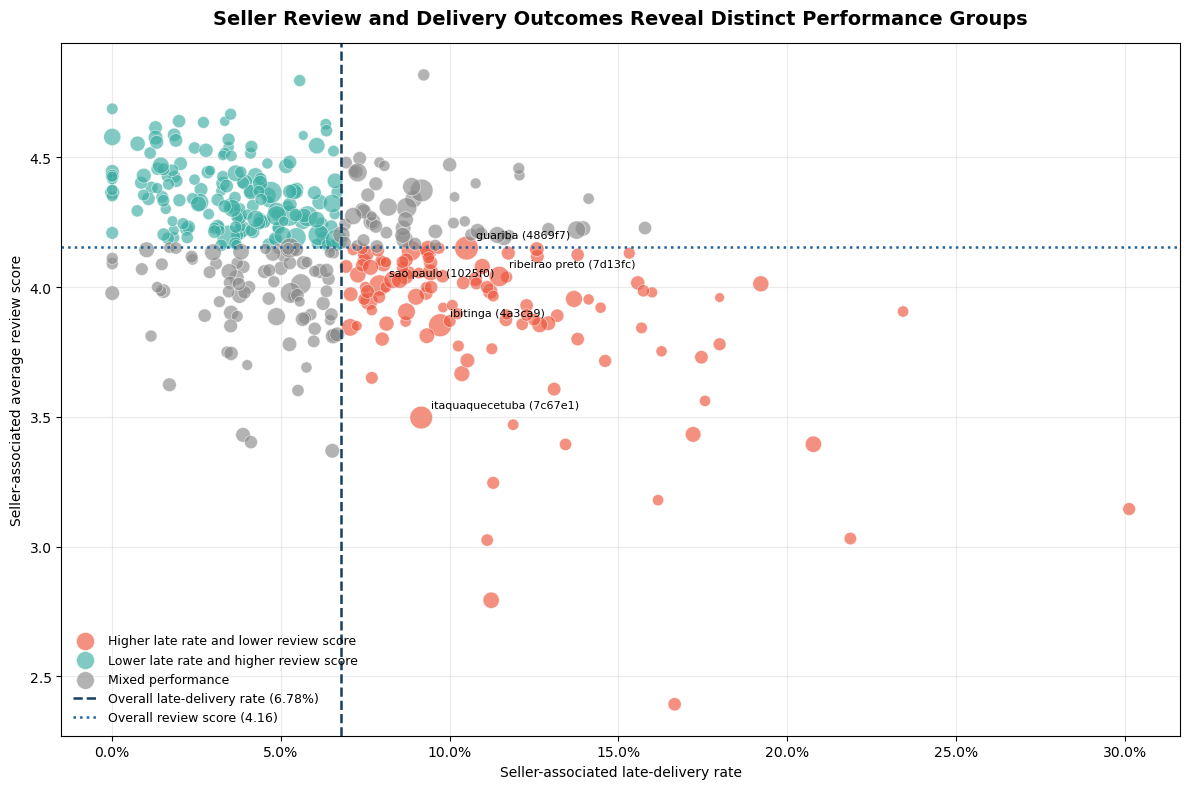

In [12]:
performance_colors = {
    "Higher late rate and lower review score":
        COLORS["negative"],
    "Lower late rate and higher review score":
        COLORS["positive"],
    "Mixed performance":
        COLORS["neutral"]
}

reliable_sellers["point_size"] = (
    30
    + 260
    * np.sqrt(
        reliable_sellers[
            "delivered_product_value"
        ]
        / reliable_sellers[
            "delivered_product_value"
        ].max()
    )
)

fig, ax = plt.subplots(figsize=(12, 8))

for group, group_data in reliable_sellers.groupby(
    "performance_group"
):
    ax.scatter(
        group_data["late_delivery_rate"],
        group_data["average_review_score"],
        s=group_data["point_size"],
        color=performance_colors[group],
        alpha=0.65,
        edgecolor="white",
        linewidth=0.5,
        label=group
    )

ax.axvline(
    overall_late_delivery_rate,
    color=COLORS["primary"],
    linestyle="--",
    linewidth=1.8,
    label=(
        "Overall late-delivery rate "
        f"({overall_late_delivery_rate:.2%})"
    )
)

ax.axhline(
    overall_review_score,
    color=COLORS["secondary"],
    linestyle=":",
    linewidth=1.8,
    label=(
        "Overall review score "
        f"({overall_review_score:.2f})"
    )
)

annotation_sellers = (
    seller_priority_candidates
    .head(5)
)

for _, seller in annotation_sellers.iterrows():
    label = (
        f"{seller['seller_city']} "
        f"({seller['seller_id'][:6]})"
    )

    ax.annotate(
        label,
        xy=(
            seller["late_delivery_rate"],
            seller["average_review_score"]
        ),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=8
    )

ax.xaxis.set_major_formatter(PercentFormatter(1))

ax.set_xlabel("Seller-associated late-delivery rate")
ax.set_ylabel("Seller-associated average review score")

ax.set_title(
    "Seller Review and Delivery Outcomes Reveal Distinct Performance Groups",
    fontsize=14,
    fontweight="bold",
    pad=14
)

ax.legend(
    frameon=False,
    fontsize=9,
    loc="lower left"
)

ax.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    IMAGES_DIR / "seller_performance_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

***Observation:*** The performance matrix identifies 111 reliable sellers associated with both above-benchmark late-delivery rates and below-benchmark review scores. Point size represents delivered product value, helping prioritize investigation while keeping review, delivery, and value as separate measures.

## 11. Multi-Seller Order Sensitivity

Recalculate seller review and delivery outcomes using only single-seller orders to assess whether shared order-level outcomes materially affect the seller comparison.

In [13]:
single_seller_bridge = (
    seller_bridge.loc[
        ~seller_bridge["is_multi_seller_order"]
    ]
    .copy()
)

single_seller_metrics = (
    single_seller_bridge
    .groupby("seller_id", as_index=False)
    .agg(
        single_seller_reviewed_orders=(
            "review_score_for_analysis",
            "count"
        ),
        single_seller_average_review_score=(
            "review_score_for_analysis",
            "mean"
        ),
        single_seller_low_satisfaction_rate=(
            "low_satisfaction_for_analysis",
            "mean"
        ),
        single_seller_valid_deliveries=(
            "late_delivery_for_analysis",
            "count"
        ),
        single_seller_late_delivery_rate=(
            "late_delivery_for_analysis",
            "mean"
        )
    )
)

seller_sensitivity = (
    reliable_sellers
    .merge(
        single_seller_metrics,
        on="seller_id",
        how="left",
        validate="one_to_one"
    )
)

seller_sensitivity = (
    seller_sensitivity.loc[
        (
            seller_sensitivity[
                "single_seller_reviewed_orders"
            ] >= minimum_reviewed_orders
        )
        & (
            seller_sensitivity[
                "single_seller_valid_deliveries"
            ] >= minimum_valid_deliveries
        )
    ]
    .copy()
)

seller_sensitivity["review_score_change"] = (
    seller_sensitivity[
        "single_seller_average_review_score"
    ]
    - seller_sensitivity[
        "average_review_score"
    ]
)

seller_sensitivity["late_rate_change_pp"] = (
    seller_sensitivity[
        "single_seller_late_delivery_rate"
    ]
    - seller_sensitivity[
        "late_delivery_rate"
    ]
) * 100

seller_sensitivity[
    "single_seller_performance_group"
] = np.select(
    [
        (
            seller_sensitivity[
                "single_seller_late_delivery_rate"
            ] > overall_late_delivery_rate
        )
        & (
            seller_sensitivity[
                "single_seller_average_review_score"
            ] < overall_review_score
        ),
        (
            seller_sensitivity[
                "single_seller_late_delivery_rate"
            ] <= overall_late_delivery_rate
        )
        & (
            seller_sensitivity[
                "single_seller_average_review_score"
            ] >= overall_review_score
        )
    ],
    [
        "Higher late rate and lower review score",
        "Lower late rate and higher review score"
    ],
    default="Mixed performance"
)

seller_sensitivity["classification_changed"] = (
    seller_sensitivity["performance_group"]
    != seller_sensitivity[
        "single_seller_performance_group"
    ]
)

sensitivity_summary = pd.DataFrame({
    "metric": [
        "Sellers meeting thresholds in both analyses",
        "Average absolute review-score change",
        "Maximum absolute review-score change",
        "Average absolute late-rate change",
        "Maximum absolute late-rate change",
        "Sellers changing performance group",
        "Performance-group change rate"
    ],
    "value": [
        len(seller_sensitivity),
        seller_sensitivity[
            "review_score_change"
        ].abs().mean(),
        seller_sensitivity[
            "review_score_change"
        ].abs().max(),
        seller_sensitivity[
            "late_rate_change_pp"
        ].abs().mean(),
        seller_sensitivity[
            "late_rate_change_pp"
        ].abs().max(),
        seller_sensitivity[
            "classification_changed"
        ].sum(),
        seller_sensitivity[
            "classification_changed"
        ].mean()
    ]
})

display(
    sensitivity_summary.style.format({
        "value": "{:,.4f}"
    })
)

print(
    "Multi-seller seller-order associations:",
    f"{seller_bridge['is_multi_seller_order'].sum():,}"
)
print(
    "Share of seller-order associations:",
    f"{seller_bridge['is_multi_seller_order'].mean():.2%}"
)

,metric,value
0,Sellers meeting thresholds in both analyses,411.0000
1,Average absolute review-score change,0.0368
2,Maximum absolute review-score change,0.2971
3,Average absolute late-rate change,0.1807
4,Maximum absolute late-rate change,2.8990
5,Sellers changing performance group,23.0000
6,Performance-group change rate,0.0560


Multi-seller seller-order associations: 2,622
Share of seller-order associations: 2.62%


***Observation:*** Multi-seller orders represent only 2.62% of seller–order associations. After excluding them, the average absolute review-score change is 0.04 points and the average late-rate change is 0.18 percentage points; 23 of 411 comparable sellers (5.60%) change performance group, indicating that the overall comparison is reasonably robust but not identical for every seller.

## 12. Seller Geographic Distribution

Summarize seller participation, delivered product value, and associated customer outcomes by seller state to identify where marketplace seller activity is concentrated.

In [14]:
seller_state_summary = (
    seller_bridge
    .groupby("seller_state", as_index=False)
    .agg(
        sellers=("seller_id", "nunique"),
        seller_order_associations=(
            "order_id",
            "size"
        ),
        delivered_seller_order_associations=(
            "is_delivered_order",
            "sum"
        ),
        item_records=(
            "seller_order_item_count",
            "sum"
        ),
        delivered_product_value=(
            "delivered_product_value",
            "sum"
        ),
        reviewed_delivered_orders=(
            "review_score_for_analysis",
            "count"
        ),
        average_review_score=(
            "review_score_for_analysis",
            "mean"
        ),
        low_satisfaction_rate=(
            "low_satisfaction_for_analysis",
            "mean"
        ),
        valid_delivery_orders=(
            "late_delivery_for_analysis",
            "count"
        ),
        late_delivery_rate=(
            "late_delivery_for_analysis",
            "mean"
        )
    )
)

seller_state_summary["seller_share"] = (
    seller_state_summary["sellers"]
    / seller_state_summary["sellers"].sum()
)

seller_state_summary["product_value_share"] = (
    seller_state_summary[
        "delivered_product_value"
    ]
    / seller_state_summary[
        "delivered_product_value"
    ].sum()
)

seller_state_summary = (
    seller_state_summary
    .sort_values(
        "delivered_product_value",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    seller_state_summary.head(10).style.format({
        "sellers": "{:,.0f}",
        "seller_order_associations": "{:,.0f}",
        "delivered_seller_order_associations":
            "{:,.0f}",
        "item_records": "{:,.0f}",
        "delivered_product_value": "R$ {:,.2f}",
        "reviewed_delivered_orders": "{:,.0f}",
        "average_review_score": "{:.2f}",
        "low_satisfaction_rate": "{:.2%}",
        "valid_delivery_orders": "{:,.0f}",
        "late_delivery_rate": "{:.2%}",
        "seller_share": "{:.2%}",
        "product_value_share": "{:.2%}"
    })
)

print(
    "Seller states represented:",
    seller_state_summary["seller_state"].nunique()
)
print(
    "Top-three state product-value share:",
    f"{seller_state_summary.head(3)['product_value_share'].sum():.2%}"
)

,seller_state,sellers,seller_order_associations,delivered_seller_order_associations,item_records,delivered_product_value,reviewed_delivered_orders,average_review_score,low_satisfaction_rate,valid_delivery_orders,late_delivery_rate,seller_share,product_value_share
0,SP,"1,849","70,950","69,401","80,342","R$ 8,509,511.46","68,927",4.11,13.86%,"69,247",7.26%,59.74%,64.36%
1,PR,349,"7,717","7,556","8,671","R$ 1,232,096.99","7,504",4.17,12.77%,"7,540",5.32%,11.28%,9.32%
2,MG,244,"7,942","7,747","8,827","R$ 977,866.31","7,695",4.22,11.06%,"7,720",4.79%,7.88%,7.40%
3,RJ,171,"4,355","4,229","4,818","R$ 820,611.59","4,199",4.22,12.36%,"4,222",7.13%,5.53%,6.21%
4,SC,190,"3,672","3,608","4,075","R$ 613,591.65","3,589",4.17,12.87%,"3,598",4.86%,6.14%,4.64%
5,RS,129,"1,991","1,964","2,199","R$ 373,412.08","1,947",4.33,8.73%,"1,959",3.11%,4.17%,2.82%
6,BA,19,569,550,643,"R$ 277,925.51",548,4.19,10.95%,549,4.92%,0.61%,2.10%
7,DF,30,824,808,899,"R$ 94,840.31",807,4.10,14.25%,807,5.33%,0.97%,0.72%
8,PE,9,406,403,448,"R$ 91,164.15",401,4.26,10.72%,403,3.72%,0.29%,0.69%
9,GO,40,463,451,520,"R$ 64,806.59",450,4.38,8.22%,450,2.89%,1.29%,0.49%


Seller states represented: 23
Top-three state product-value share: 81.08%


***Observation:*** Seller activity is geographically concentrated across 23 represented states. São Paulo contains 59.74% of sellers and accounts for 64.36% of delivered product value, while São Paulo, Paraná, and Minas Gerais together account for 81.08% of delivered product value.

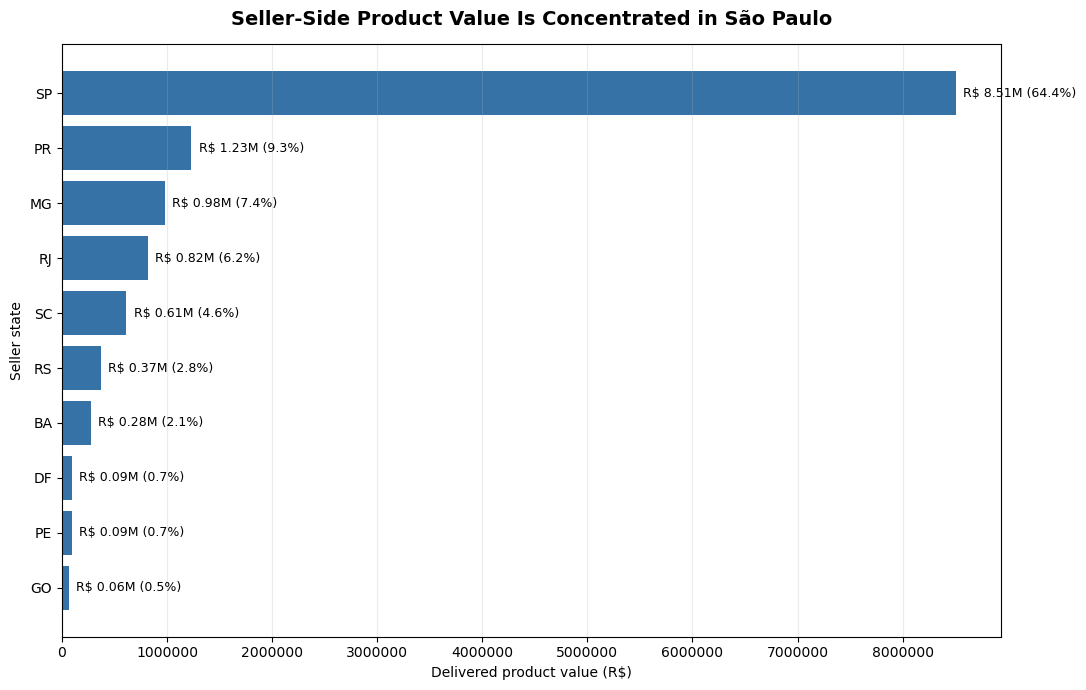

In [15]:
state_plot = (
    seller_state_summary
    .head(10)
    .sort_values(
        "delivered_product_value"
    )
)

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    state_plot["seller_state"],
    state_plot["delivered_product_value"],
    color=COLORS["secondary"],
    alpha=0.9
)

for bar, value, share in zip(
    bars,
    state_plot["delivered_product_value"],
    state_plot["product_value_share"]
):
    ax.text(
        value
        + seller_state_summary[
            "delivered_product_value"
        ].max() * 0.008,
        bar.get_y() + bar.get_height() / 2,
        f"R$ {value / 1_000_000:.2f}M ({share:.1%})",
        va="center",
        fontsize=9
    )

ax.set_xlabel("Delivered product value (R$)")
ax.set_ylabel("Seller state")

ax.set_title(
    "Seller-Side Product Value Is Concentrated in São Paulo",
    fontsize=14,
    fontweight="bold",
    pad=14
)

ax.ticklabel_format(
    axis="x",
    style="plain"
)

ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)

plt.tight_layout()

plt.savefig(
    IMAGES_DIR / "seller_state_product_value.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

***Observation:*** São Paulo dominates the seller side of the marketplace with R$8.51 million in delivered product value, representing 64.36% of the total. This geographic concentration describes seller location and associated transaction value, not regional profitability.

## 13. Seller Investigation Candidates

Prioritize reliable sellers associated with above-benchmark late-delivery rates and below-benchmark review scores, ranking them by delivered product value to support further operational review.

In [16]:
top_priority_candidates = (
    seller_priority_candidates
    .head(10)
    .copy()
)

top_priority_candidates["product_value_share"] = (
    top_priority_candidates[
        "delivered_product_value"
    ]
    / seller_performance[
        "delivered_product_value"
    ].sum()
)

display(
    top_priority_candidates.style.format({
        "delivered_orders": "{:,.0f}",
        "delivered_product_value": "R$ {:,.2f}",
        "product_value_share": "{:.2%}",
        "average_review_score": "{:.2f}",
        "low_satisfaction_rate": "{:.2%}",
        "late_delivery_rate": "{:.2%}",
        "average_delivery_days": "{:.2f}"
    })
)

print(
    "Top-10 candidate delivered product value:",
    (
        "R$ "
        f"{top_priority_candidates['delivered_product_value'].sum():,.2f}"
    )
)

print(
    "Top-10 candidate share of delivered product value:",
    f"{top_priority_candidates['product_value_share'].sum():.2%}"
)

,seller_id,seller_city,seller_state,delivered_orders,delivered_product_value,average_review_score,low_satisfaction_rate,late_delivery_rate,average_delivery_days,product_value_share
0,4869f7a5dfa277a7dca6462dcf3b52b2,guariba,SP,"1,124","R$ 226,987.93",4.15,13.08%,10.50%,15.06,1.72%
1,4a3ca9315b744ce9f8e9374361493884,ibitinga,SP,"1,772","R$ 196,882.12",3.85,18.48%,9.72%,14.50,1.49%
2,7c67e1448b00f6e969d365cea6b010ab,itaquaquecetuba,SP,973,"R$ 186,570.05",3.50,25.44%,9.16%,22.36,1.41%
3,1025f0e2d44d7041d6cf58b6550e0bfa,sao paulo,SP,910,"R$ 138,208.56",4.01,16.96%,7.92%,12.40,1.05%
4,7d13fca15225358621be4086e1eb0964,ribeirao preto,SP,558,"R$ 112,436.18",4.04,17.12%,11.47%,15.73,0.85%
5,1f50f920176fa81dab994f9023523100,sao jose do rio preto,SP,"1,399","R$ 106,655.71",4.14,13.99%,8.86%,15.81,0.81%
6,04308b1ee57b6625f47df1d56f00eedf,bombinhas,SC,92,"R$ 58,991.80",3.95,19.57%,7.61%,18.88,0.45%
7,522620dcb18a6b31cd7bdf73665113a9,cascavel,PR,172,"R$ 56,690.49",3.91,18.93%,8.72%,15.40,0.43%
8,7ddcbb64b5bc1ef36ca8c151f6ec77df,sao paulo,SP,325,"R$ 54,435.66",4.03,15.22%,8.31%,12.71,0.41%
9,25c5c91f63607446a97b143d2d535d31,itauna,MG,156,"R$ 54,208.78",3.85,19.35%,7.05%,14.47,0.41%


Top-10 candidate delivered product value: R$ 1,192,067.28
Top-10 candidate share of delivered product value: 9.02%


***Observation:*** The ten highest-value investigation candidates account for R$1.19 million, or 9.02% of delivered product value. They combine meaningful transaction activity with above-benchmark late-delivery rates and below-benchmark review scores, but should be investigated rather than automatically classified as underperforming.

## 14. Final Validation and Export Preparation

Confirm that seller-level records, financial measures, comparison groups, geographic summaries, and performance rates remain complete and internally consistent.

In [17]:
final_validation = pd.DataFrame([
    {
        "validation_check": "Seller rows represented",
        "result": len(seller_performance),
        "expected": 3_095
    },
    {
        "validation_check": "Duplicate seller IDs",
        "result": seller_performance[
            "seller_id"
        ].duplicated().sum(),
        "expected": 0
    },
    {
        "validation_check":
            "Duplicate seller-order combinations",
        "result": seller_bridge[
            ["seller_id", "order_id"]
        ].duplicated().sum(),
        "expected": 0
    },
    {
        "validation_check": "Item records represented",
        "result": seller_performance[
            "item_records"
        ].sum(),
        "expected": seller_bridge[
            "seller_order_item_count"
        ].sum()
    },
    {
        "validation_check":
            "Delivered product value represented",
        "result": round(
            seller_performance[
                "delivered_product_value"
            ].sum(),
            2
        ),
        "expected": round(
            seller_bridge[
                "delivered_product_value"
            ].sum(),
            2
        )
    },
    {
        "validation_check":
            "State product value represented",
        "result": round(
            seller_state_summary[
                "delivered_product_value"
            ].sum(),
            2
        ),
        "expected": round(
            seller_performance[
                "delivered_product_value"
            ].sum(),
            2
        )
    },
    {
        "validation_check":
            "Reliable sellers represented",
        "result": len(reliable_sellers),
        "expected": 417
    },
    {
        "validation_check":
            "Priority candidates represented",
        "result": len(seller_priority_candidates),
        "expected": 111
    },
    {
        "validation_check":
            "Invalid reliable review scores",
        "result": (
            ~reliable_sellers[
                "average_review_score"
            ].between(1, 5)
        ).sum(),
        "expected": 0
    },
    {
        "validation_check":
            "Invalid reliable late-delivery rates",
        "result": (
            ~reliable_sellers[
                "late_delivery_rate"
            ].between(0, 1)
        ).sum(),
        "expected": 0
    },
    {
        "validation_check":
            "Missing seller locations",
        "result": seller_performance[
            ["seller_city", "seller_state"]
        ].isna().any(axis=1).sum(),
        "expected": 0
    }
])

final_validation["status"] = np.where(
    final_validation["result"]
    == final_validation["expected"],
    "Passed",
    "Failed"
)

display(final_validation)

,validation_check,result,expected,status
0,Seller rows represented,"3,095.00","3,095.00",Passed
1,Duplicate seller IDs,0.00,0.00,Passed
2,Duplicate seller-order combinations,0.00,0.00,Passed
3,Item records represented,"112,650.00","112,650.00",Passed
4,Delivered product value represented,"13,221,498.11","13,221,498.11",Passed
5,State product value represented,"13,221,498.11","13,221,498.11",Passed
6,Reliable sellers represented,417.00,417.00,Passed
7,Priority candidates represented,111.00,111.00,Passed
8,Invalid reliable review scores,0.00,0.00,Passed
9,Invalid reliable late-delivery rates,0.00,0.00,Passed


## 15. Export Analytical Outputs

Export the seller-level performance, concentration, comparison, sensitivity, geographic, and validation tables for dashboard development and reporting.

In [18]:
seller_methodology = pd.DataFrame({
    "parameter": [
        "minimum_reviewed_delivered_orders",
        "minimum_valid_delivery_orders",
        "overall_review_score_benchmark",
        "overall_late_delivery_rate_benchmark",
        "reliable_sellers",
        "priority_candidate_definition"
    ],
    "value": [
        minimum_reviewed_orders,
        minimum_valid_deliveries,
        round(overall_review_score, 4),
        round(overall_late_delivery_rate, 6),
        len(reliable_sellers),
        (
            "Reliable seller with an above-benchmark "
            "late-delivery rate and below-benchmark "
            "average review score"
        )
    ]
})

export_files = {
    "seller_performance_detailed.csv":
        seller_performance,
    "reliable_seller_performance.csv":
        reliable_sellers,
    "seller_value_concentration.csv":
        seller_concentration,
    "seller_performance_groups.csv":
        performance_group_summary,
    "seller_priority_candidates.csv":
        seller_priority_candidates,
    "seller_multi_seller_sensitivity.csv":
        seller_sensitivity,
    "seller_state_summary.csv":
        seller_state_summary,
    "seller_analysis_methodology.csv":
        seller_methodology,
    "seller_analysis_validation.csv":
        final_validation
}

for filename, dataframe in export_files.items():
    dataframe.to_csv(
        DATA_DIR / filename,
        index=False
    )

all_files_created = all(
    (DATA_DIR / filename).exists()
    for filename in export_files
)

print(
    "Seller-analysis files exported:",
    len(export_files)
)
print(
    "All seller-analysis files created:",
    all_files_created
)

Seller-analysis files exported: 9
All seller-analysis files created: True


## Conclusion

***Key findings:***

- The analysis represents 3,095 sellers, 112,650 item records, and R$13.22 million in delivered product value.
- Seller activity is highly concentrated: the top 5% of sellers account for 53.80% of delivered product value, while the top 20% account for 83.14%.
- The ten largest sellers account for 13.27% of delivered product value, but their review and delivery outcomes vary considerably.
- Applying minimum thresholds of 50 reviewed orders and 50 valid deliveries creates a reliable comparison group of 417 sellers.
- Among these sellers, 111 are associated with both above-benchmark late-delivery rates and below-benchmark review scores.
- The ten highest-value investigation candidates account for R$1.19 million, or 9.02% of delivered product value.
- Multi-seller orders represent 2.62% of seller–order associations. Excluding them changes the performance group for 5.60% of comparable sellers.
- São Paulo contains 59.74% of sellers and accounts for 64.36% of delivered product value.

***Interpretation:*** Seller value, review outcomes, and delivery performance vary substantially across the marketplace. The identified candidates provide a focused group for additional operational investigation, not a definitive ranking of seller quality.

***Limitations:*** Reviews and delivery timestamps are recorded at order level, so outcomes associated with a seller cannot be attributed solely to that seller. Product value represents listed item prices associated with delivered orders and does not represent seller profit, commission, or net revenue.

***Outputs:*** Seller-level performance, reliable comparison groups, concentration measures, priority candidates, multi-seller sensitivity results, geographic summaries, methodology, and validation results were exported.